In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = '/content/drive/MyDrive/CV project/YOLO_Object_Detection'

dirs = [
    'images/input',
    'images/output',
    'darknet',
    'weights',
    'cfg',
    'data',
    'src',
]

for d in dirs:
    os.makedirs(f'{PROJECT_ROOT}/{d}', exist_ok=True)

print("✓ Drive mounted and folders created")
print(f"  Project root: {PROJECT_ROOT}")

Mounted at /content/drive
✓ Drive mounted and folders created
  Project root: /content/drive/MyDrive/CV project/YOLO_Object_Detection


In [10]:
import torch

print("=== GPU Check ===")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Also check via nvidia-smi
!nvidia-smi

=== GPU Check ===
CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB
Tue Mar 31 00:21:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |      

In [2]:
import os

# Clone Darknet into Colab's local storage (not Drive — faster compilation)
!git clone https://github.com/AlexeyAB/darknet /content/darknet
os.chdir('/content/darknet')

# Enable GPU and OpenCV in the Makefile
# These are flags inside the Makefile that default to 0
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/LIBSO=0/LIBSO=1/' Makefile

# LIBSO=1 builds darknet as a shared library (.so file)
# This is what lets us call Darknet from Python

print("✓ Makefile configured")
print("Compiling Darknet (takes ~2 min)...")

!make 2>&1 | tail -5   # show only last 5 lines of build output

print("\n✓ Compilation done")

Cloning into '/content/darknet'...
remote: Enumerating objects: 15941, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 15941 (delta 14), reused 9 (delta 8), pack-reused 15909 (from 2)
Receiving objects: 100% (15941/15941), 14.52 MiB | 16.95 MiB/s, done.
Resolving deltas: 100% (10720/10720), done.
✓ Makefile configured
Compiling Darknet (takes ~2 min)...
./src/image_opencv.cpp:16:10: fatal error: opencv2/core/version.hpp: No such file or directory
   16 | #include <opencv2/core/version.hpp>
      |          ^~~~~~~~~~~~~~~~~~~~~~~~~~
compilation terminated.
make: *** [Makefile:198: obj/image_opencv.o] Error 1

✓ Compilation done


In [11]:
import os

# Check the shared library was built
so_path  = '/content/darknet/libdarknet.so'
exe_path = '/content/darknet/darknet'

print("=== Darknet build check ===")
print(f"libdarknet.so exists : {os.path.exists(so_path)}")
print(f"darknet exe exists   : {os.path.exists(exe_path)}")

if os.path.exists(so_path):
    size_mb = os.path.getsize(so_path) / (1024 * 1024)
    print(f"libdarknet.so size   : {size_mb:.1f} MB  (expect ~8-12 MB)")

# Quick test — run darknet with no args, should print usage
print("\n--- Darknet smoke test ---")
!./darknet 2>&1 | head -3

=== Darknet build check ===
libdarknet.so exists : True
darknet exe exists   : True
libdarknet.so size   : 4.9 MB  (expect ~8-12 MB)

--- Darknet smoke test ---
usage: ./darknet <function>


In [5]:
# Install OpenCV C++ development headers
!apt-get install -y libopencv-dev

# Verify OpenCV is now findable
!pkg-config --cflags opencv4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libilmbase25
  libopencv-calib3d-dev libopencv-calib3d4.5d libopencv-contrib-dev
  libopencv-contrib4.5d libopencv-core-dev libopencv-core4.5d
  libopencv-dnn-dev libopencv-dnn4.5d libopencv-features2d-dev
  libopencv-features2d4.5d libopencv-flann-dev libopencv-flann4.5d
  libopencv-highgui-dev libopencv-highgui4.5d libopencv-imgcodecs-dev
  libopencv-imgcodecs4.5d libopen

In [12]:
import os

WEIGHTS_DIR = f'{PROJECT_ROOT}/weights'
CFG_DIR     = f'{PROJECT_ROOT}/cfg'
DATA_DIR    = f'{PROJECT_ROOT}/data'

# YOLOv4 pretrained weights (trained on COCO 80 classes)
print("Downloading YOLOv4 weights (245MB)...")
!wget -q --show-progress \
    https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights \
    -O "{WEIGHTS_DIR}/yolov4.weights"

# YOLOv4 config file
print("\nDownloading YOLOv4 cfg...")
!wget -q \
    https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg \
    -O "{CFG_DIR}/yolov4.cfg"

# COCO class names (80 categories)
print("Downloading COCO class names...")
!wget -q \
    https://raw.githubusercontent.com/AlexeyAB/darknet/master/data/coco.names \
    -O "{DATA_DIR}/coco.names"

# Verify
weights_mb = os.path.getsize(f'{WEIGHTS_DIR}/yolov4.weights') / (1024*1024)
print(f"\n✓ yolov4.weights : {weights_mb:.1f} MB  (expect ~245 MB)")
print(f"✓ yolov4.cfg     : {os.path.getsize(f'{CFG_DIR}/yolov4.cfg')} bytes")
print(f"✓ coco.names     : {os.path.getsize(f'{DATA_DIR}/coco.names')} bytes")

/content/drive/MyDr 100%[===================>] 245.78M  62.5MB/s    in 3.9s    


✓ yolov4.weights : 245.8 MB  (expect ~245 MB)
✓ yolov4.cfg     : 12231 bytes
✓ coco.names     : 625 bytes


In [15]:
import os

IMG_DIR = f'{PROJECT_ROOT}/images/input'

# Download reliable test images
!wget -q "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg" \
    -O "{IMG_DIR}/dogs.jpg"

!wget -q "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg" \
    -O "{IMG_DIR}/cat.jpg"

!wget -q "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/1200px-Camponotus_flavomarginatus_ant.jpg" \
    -O "{IMG_DIR}/street.jpg"

# Verify downloads
print("Downloaded images:")
for f in os.listdir(IMG_DIR):
    size_kb = os.path.getsize(f'{IMG_DIR}/{f}') / 1024
    print(f"  {f}  ({size_kb:.0f} KB)")

Downloaded images:
  street.jpg  (95 KB)
  kitchen.jpg  (0 KB)
  dogs.jpg  (246 KB)
  cat.jpg  (210 KB)


In [16]:
import os

os.chdir('/content/darknet')

CFG     = f'{PROJECT_ROOT}/cfg/yolov4.cfg'
WEIGHTS = f'{PROJECT_ROOT}/weights/yolov4.weights'
IMAGE   = f'{PROJECT_ROOT}/images/input/dogs.jpg'
NAMES   = f'{PROJECT_ROOT}/data/coco.names'
OUTPUT  = f'{PROJECT_ROOT}/images/output/darknet_test.jpg'

print("Running Darknet detection on dogs.jpg...")
print("(First run may take ~10s to load weights into GPU)\n")

!./darknet detector test \
    cfg/coco.data \
    "{CFG}" \
    "{WEIGHTS}" \
    "{IMAGE}" \
    -thresh 0.5 \
    -dont_show \
    -out "{OUTPUT}" \
    2>&1 | grep -E "YOLO|FPS|Objects|%|Loading"

Running Darknet detection on dogs.jpg...
(First run may take ~10s to load weights into GPU)

Loading weights from /content/drive/MyDrive/CV project/YOLO_Object_Detection/weights/yolov4.weights...net.optimized_memory = 0 
/content/drive/MyDrive/CV project/YOLO_Object_Detection/images/input/dogs.jpg: Predicted in 126.932000 milli-seconds.
dog: 96%


In [17]:
CFG_PATH = f'{PROJECT_ROOT}/cfg/yolov4.cfg'

with open(CFG_PATH, 'r') as f:
    lines = f.readlines()

# Print the first section and the net section
print("=== First 30 lines of yolov4.cfg ===\n")
for line in lines[:30]:
    print(line.rstrip())

# Find key parameters
print("\n=== Key network parameters ===")
for line in lines:
    line = line.strip()
    if line.startswith('width=') or \
       line.startswith('height=') or \
       line.startswith('classes=') or \
       line.startswith('anchors='):
        print(f"  {line}")

=== First 30 lines of yolov4.cfg ===

[net]
batch=64
subdivisions=8
# Training
#width=512
#height=512
width=608
height=608
channels=3
momentum=0.949
decay=0.0005
angle=0
saturation = 1.5
exposure = 1.5
hue=.1

learning_rate=0.0013
burn_in=1000
max_batches = 500500
policy=steps
steps=400000,450000
scales=.1,.1

#cutmix=1
mosaic=1

#:104x104 54:52x52 85:26x26 104:13x13 for 416

[convolutional]
batch_normalize=1

=== Key network parameters ===
  width=608
  height=608
  classes=80
  classes=80
  classes=80


In [18]:
NAMES_PATH = f'{PROJECT_ROOT}/data/coco.names'

with open(NAMES_PATH, 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"Total classes : {len(classes)}")
print(f"\nAll 80 COCO classes:")
for i, cls in enumerate(classes):
    print(f"  {i:2d}: {cls}")

Total classes : 80

All 80 COCO classes:
   0: person
   1: bicycle
   2: car
   3: motorbike
   4: aeroplane
   5: bus
   6: train
   7: truck
   8: boat
   9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: sofa
  58: pottedplant
  59: bed
  60: diningtable
  61: toilet
  62: tvmonitor
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: ove

In [23]:
%%writefile "{PROJECT_ROOT}/src/detector.py"

import cv2
import numpy as np
from pathlib import Path


class YOLODetector:
    """
    YOLOv4 object detector using OpenCV's dnn module.

    OpenCV dnn loads Darknet's .cfg and .weights files directly
    and runs inference on GPU via CUDA backend — same weights,
    same architecture, full Python control over outputs.

    Args:
        cfg_path     : path to yolov4.cfg
        weights_path : path to yolov4.weights
        names_path   : path to coco.names
        conf_thresh  : confidence threshold — discard below this
        nms_thresh   : NMS IoU threshold — merge boxes above this
        input_size   : network input size (must match cfg width/height)
        use_gpu      : use CUDA backend if available
    """

    def __init__(self, cfg_path, weights_path, names_path,
                 conf_thresh=0.5, nms_thresh=0.4,
                 input_size=416, use_gpu=False):

        self.conf_thresh = conf_thresh
        self.nms_thresh  = nms_thresh
        self.input_size  = input_size

        # ── Load class names ─────────────────────────────────────────────────
        with open(names_path, 'r') as f:
            self.classes = [line.strip() for line in f.readlines()]
        print(f"Loaded {len(self.classes)} class names")

        # ── Load network ──────────────────────────────────────────────────────
        print("Loading YOLOv4 network via OpenCV dnn...")
        self.net = cv2.dnn.readNetFromDarknet(cfg_path, weights_path)

        # ── Set backend ───────────────────────────────────────────────────────
        # CUDA backend uses GPU — same as Darknet's GPU=1 compilation
        # Falls back to CPU if CUDA not available
        if use_gpu:
            self.net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
            self.net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)
            print("Backend: CUDA (GPU)")
        else:
            self.net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
            self.net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
            print("Backend: OpenCV (CPU)")

        # ── Get output layer names ────────────────────────────────────────────
        # YOLOv4 has 3 YOLO output layers — one for each detection scale
        # small objects (large feature map), medium, large objects (small map)
        layer_names        = self.net.getLayerNames()
        unconnected        = self.net.getUnconnectedOutLayers()
        self.output_layers = [layer_names[i - 1] for i in unconnected.flatten()]
        print(f"Output layers    : {self.output_layers}")

        # ── Fixed color per class for visualization ───────────────────────────
        np.random.seed(42)
        self.colors = np.random.randint(50, 230,
                                        size=(len(self.classes), 3),
                                        dtype=np.uint8)

        print("✓ YOLODetector ready\n")


    def preprocess(self, image):
        """
        Convert image to blob — the format YOLOv4 expects.

        blobFromImage does three things:
        1. Resizes image to input_size × input_size
        2. Normalizes pixel values from [0,255] to [0,1] (scale=1/255)
        3. Converts BGR → RGB (swapRB=True) since YOLO was trained on RGB

        Output shape: [1, 3, 416, 416]
        """
        blob = cv2.dnn.blobFromImage(
            image,
            scalefactor = 1/255.0,
            size        = (self.input_size, self.input_size),
            mean        = (0, 0, 0),
            swapRB      = True,
            crop        = False,
        )
        return blob


    def postprocess(self, outputs, img_h, img_w):
        """
        Parse raw YOLO outputs into boxes, confidences, class ids.

        Raw output from each YOLO layer:
            shape: [num_detections, 5 + num_classes]
            columns: [cx, cy, w, h, objectness, class_0, class_1, ...]

        cx, cy, w, h are normalized to [0,1] relative to image size.
        objectness = confidence that ANY object is present.
        class scores = probability of each specific class given object present.
        Final confidence = objectness × class_score.
        """
        boxes       = []
        confidences = []
        class_ids   = []

        for output in outputs:
            for detection in output:
                # First 4 values are box coords, 5th is objectness
                scores     = detection[5:]        # one score per class
                class_id   = np.argmax(scores)    # most likely class
                confidence = scores[class_id] * detection[4]  # final conf

                if confidence < self.conf_thresh:
                    continue

                # Convert normalized coords back to pixel coords
                cx = int(detection[0] * img_w)
                cy = int(detection[1] * img_h)
                w  = int(detection[2] * img_w)
                h  = int(detection[3] * img_h)

                # cv2.dnn gives center x,y — convert to top-left x,y
                x = cx - w // 2
                y = cy - h // 2

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

        # ── Non-Max Suppression ───────────────────────────────────────────────
        # Without NMS we'd get multiple overlapping boxes for the same object
        # NMS keeps the highest confidence box and removes others that
        # overlap it by more than nms_thresh IoU
        indices = cv2.dnn.NMSBoxes(
            boxes, confidences,
            self.conf_thresh,
            self.nms_thresh
        )

        final_boxes       = []
        final_confidences = []
        final_class_ids   = []

        if len(indices) > 0:
            for i in indices.flatten():
                final_boxes.append(boxes[i])
                final_confidences.append(confidences[i])
                final_class_ids.append(class_ids[i])

        return final_boxes, final_confidences, final_class_ids


    def detect(self, image):
        """
        Full detection pipeline on one image.

        Args:
            image : BGR numpy array (as loaded by cv2.imread)

        Returns:
            boxes       : list of [x, y, w, h] in pixel coords
            confidences : list of float confidence scores
            class_ids   : list of int class indices
        """
        img_h, img_w = image.shape[:2]

        # Preprocess
        blob = self.preprocess(image)
        self.net.setInput(blob)

        # Forward pass through all 3 YOLO output layers
        outputs = self.net.forward(self.output_layers)

        # Postprocess — filter + NMS
        boxes, confidences, class_ids = self.postprocess(
            outputs, img_h, img_w
        )

        return boxes, confidences, class_ids


    def get_class_name(self, class_id):
        """Return class name string for a given class id."""
        return self.classes[class_id] if class_id < len(self.classes) else '?'


    def get_color(self, class_id):
        """Return BGR color tuple for a given class id."""
        color = self.colors[class_id]
        return (int(color[0]), int(color[1]), int(color[2]))

Overwriting /content/drive/MyDrive/CV project/YOLO_Object_Detection/src/detector.py


In [24]:
import sys
for mod in list(sys.modules.keys()):
    if 'detector' in mod:
        del sys.modules[mod]

sys.path.append(f'{PROJECT_ROOT}/src')
from detector import YOLODetector
import cv2, time

CFG_PATH     = f'{PROJECT_ROOT}/cfg/yolov4.cfg'
WEIGHTS_PATH = f'{PROJECT_ROOT}/weights/yolov4.weights'
NAMES_PATH   = f'{PROJECT_ROOT}/data/coco.names'

# Initialize detector with CPU backend
detector = YOLODetector(
    cfg_path     = CFG_PATH,
    weights_path = WEIGHTS_PATH,
    names_path   = NAMES_PATH,
    conf_thresh  = 0.5,
    nms_thresh   = 0.4,
    input_size   = 416,
    use_gpu      = False,
)

# Run detection on dogs.jpg
image = cv2.imread(f'{PROJECT_ROOT}/images/input/dogs.jpg')
print(f"Image shape: {image.shape}")

start = time.time()
boxes, confidences, class_ids = detector.detect(image)
elapsed = (time.time() - start) * 1000

print(f"\nInference time : {elapsed:.1f} ms")
print(f"Detections     : {len(boxes)}")
print(f"\nResults:")
for box, conf, cls_id in zip(boxes, confidences, class_ids):
    name = detector.get_class_name(cls_id)
    print(f"  {name:<15} {conf:.2f}   box: {box}")

print("\n✓ Phase 2 complete!")

Loaded 80 class names
Loading YOLOv4 network via OpenCV dnn...
Backend: OpenCV (CPU)
Output layers    : ['yolo_139', 'yolo_150', 'yolo_161']
✓ YOLODetector ready

Image shape: (989, 1200, 3)

Inference time : 2620.4 ms
Detections     : 1

Results:
  dog             0.98   box: [94, 51, 1030, 902]

✓ Phase 2 complete!


In [33]:
%%writefile "{PROJECT_ROOT}/src/visualizer.py"

import cv2
import numpy as np
from pathlib import Path


def draw_detections(image, boxes, confidences, class_ids,
                    classes, colors, show_conf=True):
    """
    Draws bounding boxes, class labels and confidence scores
    on the image using OpenCV.

    Args:
        image      : BGR numpy array
        boxes      : list of [x, y, w, h]
        confidences: list of float scores
        class_ids  : list of int class indices
        classes    : list of class name strings
        colors     : numpy array of BGR colors per class
        show_conf  : whether to show confidence score on label

    Returns:
        output : annotated BGR image (copy of input)
    """
    output = image.copy()

    for box, conf, cls_id in zip(boxes, confidences, class_ids):
        x, y, w, h = box
        color = tuple(int(c) for c in colors[cls_id])
        label = f"{classes[cls_id]} {conf:.2f}" if show_conf \
                else classes[cls_id]

        # ── Bounding box ──────────────────────────────────────────────────────
        cv2.rectangle(output, (x, y), (x + w, y + h), color, 2)

        # ── Label background ──────────────────────────────────────────────────
        font       = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness  = 1
        (tw, th), baseline = cv2.getTextSize(
            label, font, font_scale, thickness
        )

        # Fill background rectangle behind text
        cv2.rectangle(output,
                      (x, y - th - baseline - 4),
                      (x + tw + 4, y),
                      color, -1)

        # ── Label text ────────────────────────────────────────────────────────
        cv2.putText(output, label,
                    (x + 2, y - baseline - 2),
                    font, font_scale,
                    (255, 255, 255), thickness,
                    cv2.LINE_AA)

    # ── Detection count ───────────────────────────────────────────────────────
    count_text = f"{len(boxes)} object(s) detected"
    cv2.putText(output, count_text,
                (10, output.shape[0] - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(output, count_text,
                (10, output.shape[0] - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (0, 0, 0), 1, cv2.LINE_AA)

    return output


def save_result(image, output_path):
    """Save annotated image to disk."""
    cv2.imwrite(str(output_path), image)


def show_in_notebook(image, title='', figsize=(12, 8)):
    """Display BGR image inline in Colab notebook."""
    import matplotlib.pyplot as plt
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.title(title, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def make_comparison_grid(original, annotated, title=''):
    """
    Stack original and annotated images side by side.
    Both images must be same height — resize annotated if needed.
    """
    if original.shape[0] != annotated.shape[0]:
        annotated = cv2.resize(
            annotated,
            (int(annotated.shape[1] * original.shape[0] / annotated.shape[0]),
             original.shape[0])
        )

    # Add column headers
    orig_labeled = original.copy()
    ann_labeled  = annotated.copy()

    for img, label in [(orig_labeled, 'Original'),
                       (ann_labeled,  'Detections')]:
        cv2.putText(img, label, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (255, 255, 255), 3, cv2.LINE_AA)
        cv2.putText(img, label, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (0, 0, 0), 1, cv2.LINE_AA)

    return np.hstack([orig_labeled, ann_labeled])

Overwriting /content/drive/MyDrive/CV project/YOLO_Object_Detection/src/visualizer.py


In [38]:
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['detector', 'visualizer']):
        del sys.modules[mod]

sys.path.append(f'{PROJECT_ROOT}/src')
from detector   import YOLODetector
from visualizer import draw_detections, save_result, make_comparison_grid
import cv2, time
from pathlib import Path

CFG_PATH     = f'{PROJECT_ROOT}/cfg/yolov4.cfg'
WEIGHTS_PATH = f'{PROJECT_ROOT}/weights/yolov4.weights'
NAMES_PATH   = f'{PROJECT_ROOT}/data/coco.names'
INPUT_DIR    = Path(f'{PROJECT_ROOT}/images/input')
OUTPUT_DIR   = Path(f'{PROJECT_ROOT}/images/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

detector = YOLODetector(
    cfg_path     = CFG_PATH,
    weights_path = WEIGHTS_PATH,
    names_path   = NAMES_PATH,
    conf_thresh  = 0.5,
    nms_thresh   = 0.4,
    input_size   = 416,
    use_gpu      = False,
)

# Process all images in input folder
img_paths = sorted(INPUT_DIR.glob('*.jpg'))
print(f"Processing {len(img_paths)} images...\n")

results_summary = []

for img_path in img_paths:
    image = cv2.imread(str(img_path))
    if image is None:
        print(f"  ✗ could not load {img_path.name}")
        continue

    start = time.time()
    boxes, confidences, class_ids = detector.detect(image)
    elapsed = (time.time() - start) * 1000

    # Draw detections
    annotated = draw_detections(
        image, boxes, confidences, class_ids,
        detector.classes, detector.colors
    )

    # Save side-by-side comparison
    grid      = make_comparison_grid(image, annotated)
    save_path = OUTPUT_DIR / f"{img_path.stem}_result.jpg"
    save_result(grid, save_path)

    # Print summary
    detected_classes = [detector.get_class_name(c) for c in class_ids]
    print(f"[{img_path.name}]")
    print(f"  Time       : {elapsed:.0f} ms")
    print(f"  Detections : {len(boxes)}")
    for cls, conf in zip(detected_classes, confidences):
        print(f"    {cls:<20} {conf:.2f}")
    print()

    results_summary.append({
        'image'     : img_path.name,
        'n_dets'    : len(boxes),
        'classes'   : detected_classes,
        'confs'     : confidences,
        'time_ms'   : elapsed,
    })

print(f"✓ Results saved to {OUTPUT_DIR}")

Loaded 80 class names
Loading YOLOv4 network via OpenCV dnn...
Backend: OpenCV (CPU)
Output layers    : ['yolo_139', 'yolo_150', 'yolo_161']
✓ YOLODetector ready

Processing 3 images...

[cat.jpg]
  Time       : 3082 ms
  Detections : 1
    cat                  0.90

[dogs.jpg]
  Time       : 1022 ms
  Detections : 1
    dog                  0.98

  ✗ could not load traffic.jpg
✓ Results saved to /content/drive/MyDrive/CV project/YOLO_Object_Detection/images/output


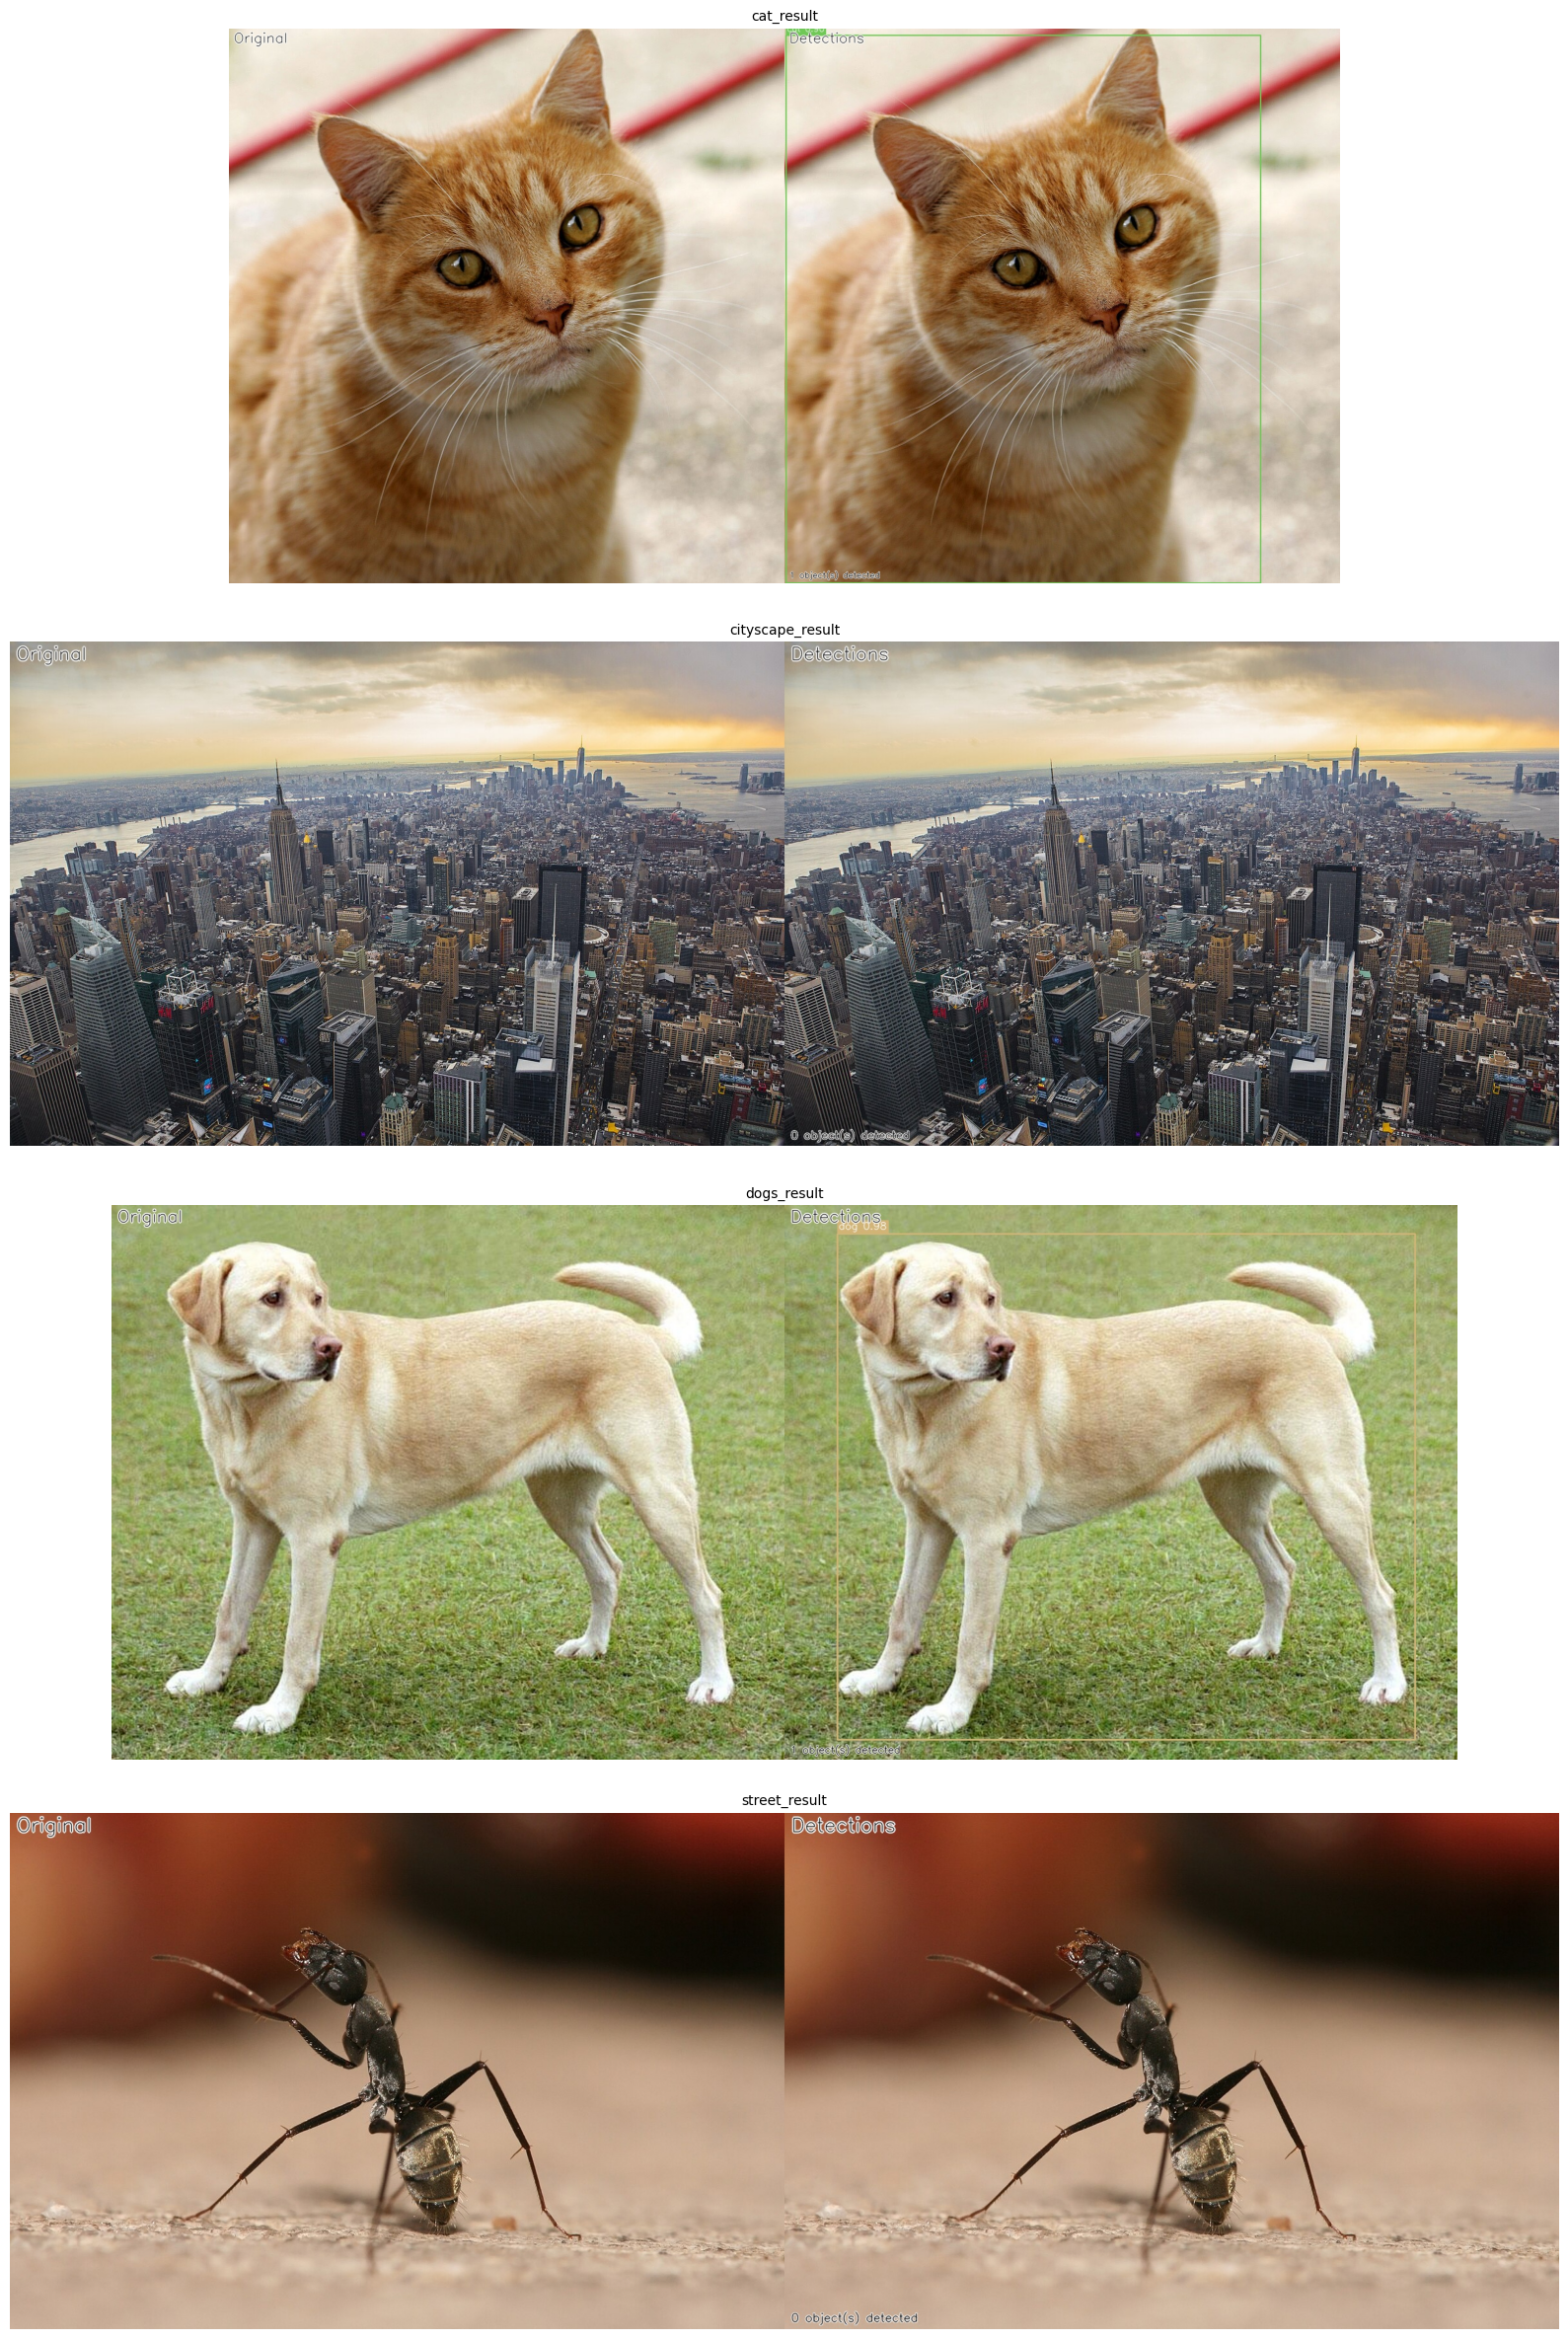

✓ Detection grid saved!


In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from pathlib import Path

result_imgs = sorted(
    Path(f'{PROJECT_ROOT}/images/output').glob('*_result.jpg')
)

fig, axes = plt.subplots(len(result_imgs), 1,
                          figsize=(16, 6 * len(result_imgs)))
if len(result_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, result_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.stem, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(
    f'{PROJECT_ROOT}/images/output/detection_grid.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("✓ Detection grid saved!")

In [37]:
import os
from pathlib import Path

IMG_DIR = f'{PROJECT_ROOT}/images/input'

# Remove everything
for f in Path(IMG_DIR).glob('*.jpg'):
    os.remove(f)

# Redownload original 3 working images
!curl -L -o "{IMG_DIR}/dogs.jpg" \
    "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/YellowLabradorLooking_new.jpg/1200px-YellowLabradorLooking_new.jpg"

!curl -L -o "{IMG_DIR}/cat.jpg" \
    "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"

!curl -L -o "{IMG_DIR}/traffic.jpg" \
    "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6e/I-80_Eastshore_Freeway.jpg/1280px-I-80_Eastshore_Freeway.jpg"

print("\nImages:")
for f in sorted(Path(IMG_DIR).glob('*.jpg')):
    kb = os.path.getsize(str(f)) / 1024
    print(f"  {f.name}  ({kb:.0f} KB)")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  246k  100  246k    0     0   349k      0 --:--:-- --:--:-- --:--:--  348k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  210k  100  210k    0     0   878k      0 --:--:-- --:--:-- --:--:--  879k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1928  100  1928    0     0   4190      0 --:--:-- --:--:-- --:--:--  4182

Images:
  cat.jpg  (210 KB)
  dogs.jpg  (246 KB)
  traffic.jpg  (2 KB)
